## **Salary Prediction Using Linear Regression**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [17]:
df = pd.read_csv("Salary_Data.csv")

print("First 5 Records:")
print(df.head())

First 5 Records:
   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0


In [18]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape:
(30, 2)

Column Names:
Index(['YearsExperience', 'Salary'], dtype='object')

Missing Values:
YearsExperience    0
Salary             0
dtype: int64


In [31]:
X = df[['YearsExperience']]
y = df['Salary']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (24, 1)
Testing Data: (6, 1)


In [21]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [22]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 25321.583011776813
Slope: 9423.815323030976


In [23]:
y_pred = model.predict(X_test)

print("Predicted Salaries:")
print(y_pred)

Predicted Salaries:
[115790.21011287  71498.27809463 102596.86866063  75267.80422384
  55477.79204548  60189.69970699]


In [24]:

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nRMSE =", rmse)
print("R2 Score =", r2)


RMSE = 7059.04362190151
R2 Score = 0.9024461774180497


In [25]:
comparison = pd.DataFrame({
    'Actual Salary': y_test,
    'Predicted Salary': y_pred
})

print(comparison)

    Actual Salary  Predicted Salary
27       112635.0     115790.210113
15        67938.0      71498.278095
23       113812.0     102596.868661
17        83088.0      75267.804224
8         64445.0      55477.792045
9         57189.0      60189.699707


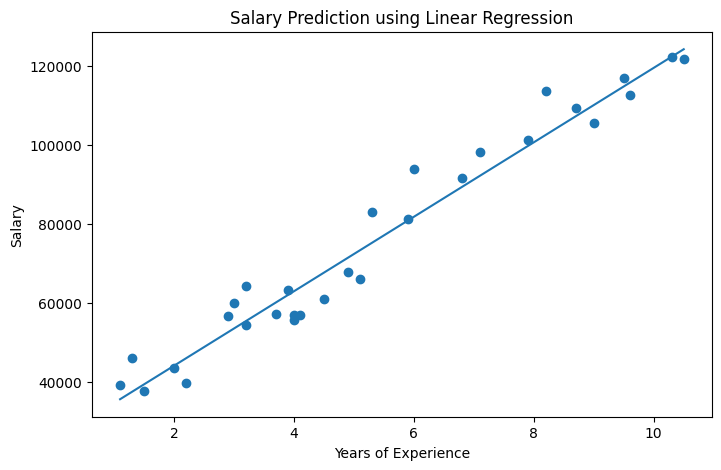

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(X, y)

plt.plot(X, model.predict(X))

plt.title("Salary Prediction using Linear Regression")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.show()

In [27]:
joblib.dump(model, "salary_prediction_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [30]:
experience = [[5]]
predicted_salary = model.predict(experience)
print("Predicted Salary for 5 Years Experience:")
print(predicted_salary[0])

Predicted Salary for 5 Years Experience:
72440.6596269317


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
